<>:132: SyntaxWarning: invalid escape sequence '\o'
<>:132: SyntaxWarning: invalid escape sequence '\o'
C:\Users\darkm\AppData\Local\Temp\ipykernel_29800\1386498559.py:132: SyntaxWarning: invalid escape sequence '\o'
  ax.set_ylabel('Masa Estelar ($M/M_\odot$)', fontsize=12, fontweight='bold')



🔍 Escaneando directorio: C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_F...

🔍 Escaneando directorio: C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_G...

🔍 Escaneando directorio: C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_K...

🔍 Escaneando directorio: C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_M...

📊 RESUMEN: ESTRELLAS ÚNICAS POR CARPETA
📂 C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_F: 14 estrella(s)
📂 C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_G: 49 estrella(s)
📂 C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_K: 45 estrella(s)
📂 C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_M: 51 estrella(s)



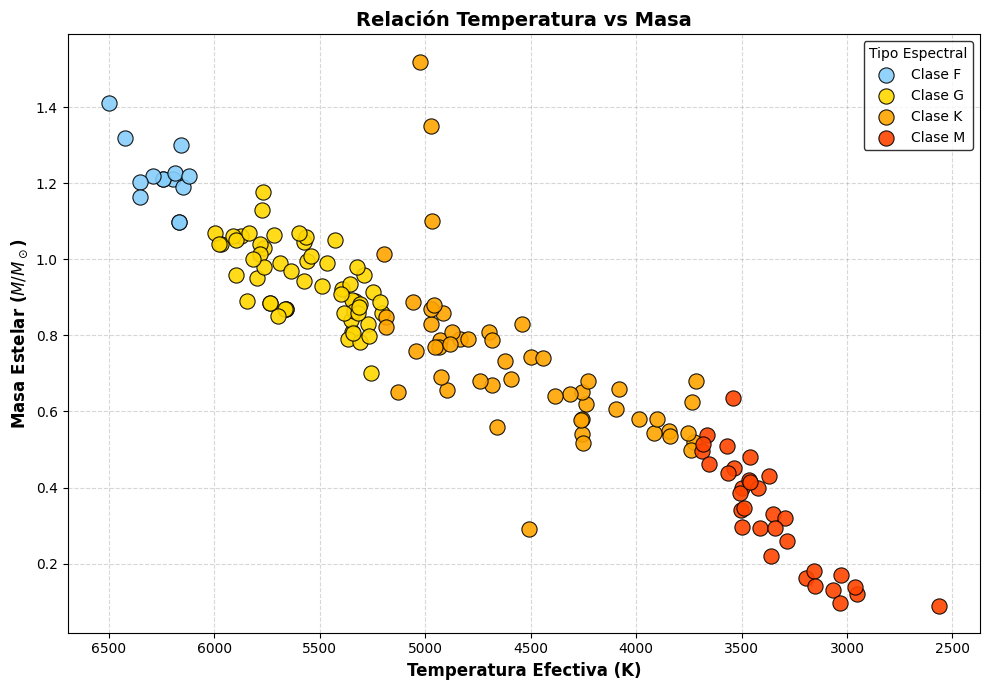


🔍 Escaneando directorio: C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_F...

🔍 Escaneando directorio: C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_G...

🔍 Escaneando directorio: C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_K...

🔍 Escaneando directorio: C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_M...

📊 RESUMEN: ESTRELLAS ÚNICAS POR CARPETA
📂 C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_F: 14 estrella(s)
📂 C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_G: 49 estrella(s)
📂 C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_K: 45 estrella(s)
📂 C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_M: 51 estrella(s)



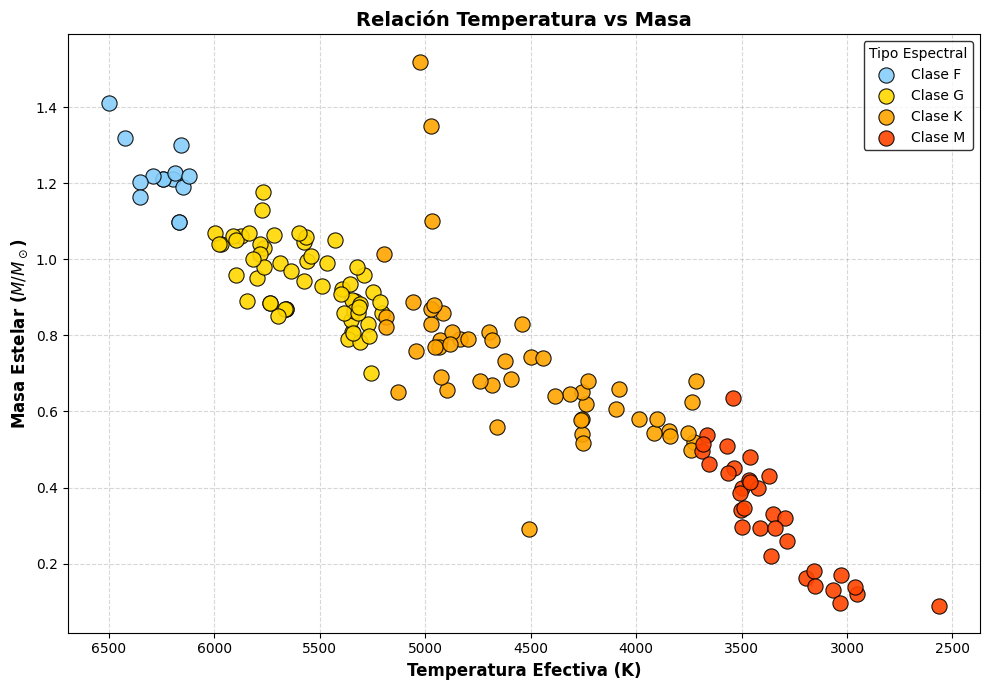

In [3]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

def solicitar_carpetas():
    carpetas = []
    try:
        cantidad = int(input("¿Cuántas carpetas deseas analizar?: "))
        for i in range(cantidad):
            ruta = input(f"Ingresa la ruta de la carpeta {i+1}: ")
            if os.path.exists(ruta):
                carpetas.append(ruta)
            else:
                print(f"⚠️ La ruta '{ruta}' no existe y será ignorada.")
    except ValueError:
        print("❌ Error: Debes ingresar un número entero válido.")
    return carpetas

def clasificar_tipo_espectral(temp):
    if temp == 0: return 'Desconocido'
    elif temp < 3700: return 'M'
    elif temp < 5200: return 'K'
    elif temp < 6000: return 'G'
    elif temp < 7500: return 'F'
    else: return 'O/B/A'

def extraer_datos_de_carpetas(directorios):
    datos_recopilados = []
    
    for directorio_raiz in directorios:
        print(f"\n🔍 Escaneando directorio: {directorio_raiz}...")
        
        for root, dirs, files in os.walk(directorio_raiz):
            resumen_file = next((f for f in files if f.endswith(" resumen.txt") or f.endswith("_resumen.txt")), None)
            readme_file = next((f for f in files if f.startswith("README") and f.endswith(".txt")), None)
            
            if resumen_file and readme_file:
                nombre_planeta = os.path.basename(root).replace("_", " ")
                ruta_resumen = os.path.join(root, resumen_file)
                ruta_readme = os.path.join(root, readme_file)
                
                try:
                    # 1. LEER RESUMEN (Campos abreviados por practicidad)
                    with open(ruta_resumen, 'r', encoding='utf-8') as f:
                        contenido_resumen = f.read()
                    
                    z_est_match = re.search(r'Total estables:\s*(\d+)', contenido_resumen, re.IGNORECASE)
                    z_est = int(z_est_match.group(1)) if z_est_match else 0
                    
                    # 2. LEER README
                    with open(ruta_readme, 'r', encoding='utf-8') as f:
                        contenido_readme = f.read()
                        
                    masa_e_match = re.search(r'Masa de.*estrella.*:\s*([0-9.,eE+-]+)', contenido_readme, re.IGNORECASE)
                    temp_e_match = re.search(r'Temperatura.*:\s*([0-9.,eE+-]+)', contenido_readme, re.IGNORECASE)
                    
                    masa_estel = float(masa_e_match.group(1).replace(',', '.')) if masa_e_match else 0.0
                    temp_estel = float(temp_e_match.group(1).replace(',', '.')) if temp_e_match else 0.0
                    
                    datos_recopilados.append({
                        "Carpeta_Origen": directorio_raiz,  # NUEVO: Guarda el origen
                        "Planeta": nombre_planeta,
                        "Masa_Estrella": masa_estel,
                        "Temp_Estrella_K": temp_estel,
                        "Zonas Estables": z_est,
                        "Tipo_Espectral": clasificar_tipo_espectral(temp_estel)
                    })
                except Exception as e:
                    print(f"❌ Error interno procesando {nombre_planeta}: {e}")
                    
    df_resultados = pd.DataFrame(datos_recopilados)
    if not df_resultados.empty:
        df_resultados["Sistema"] = df_resultados["Planeta"].apply(lambda x: str(x).rsplit(" ", 1)[0])
        df_resultados["Num_Planetas"] = df_resultados.groupby("Sistema")["Planeta"].transform("count")
        
        # Filtrar duplicados para graficar y contar solo una estrella por sistema
        df_estrellas = df_resultados.drop_duplicates(subset=['Sistema']).copy()
        
        # NUEVO: Conteo de estrellas por carpeta
        print("\n" + "="*45)
        print("📊 RESUMEN: ESTRELLAS ÚNICAS POR CARPETA")
        print("="*45)
        conteo_carpetas = df_estrellas.groupby("Carpeta_Origen")["Sistema"].count()
        for carpeta, cantidad in conteo_carpetas.items():
            print(f"📂 {carpeta}: {cantidad} estrella(s)")
        print("="*45 + "\n")
        
        generar_diagrama_hr_masa(df_estrellas)
        
    return df_resultados

def generar_diagrama_hr_masa(df_estrellas):
    df_plot = df_estrellas[df_estrellas["Temp_Estrella_K"] > 0]
    
    if df_plot.empty:
        print("⚠️ No se encontraron datos de temperatura para generar el diagrama.")
        return

    # Colores más oscuros/visibles adaptados para fondo blanco
    colores = {
        'F': '#87CEFA', # Azul claro
        'G': '#FFD700', # Amarillo oro
        'K': '#FFA500', # Naranja
        'M': '#FF4500', # Rojo anaranjado
        'O/B/A': '#4169E1', # Azul rey
        'Desconocido': 'grey'
    }
    
    # Se usa el estilo por defecto (fondo blanco)
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(10, 7))
    
    for tipo in ['F', 'G', 'K', 'M']:
        subset = df_plot[df_plot['Tipo_Espectral'] == tipo]
        if not subset.empty:
            ax.scatter(
                subset['Temp_Estrella_K'], 
                subset['Masa_Estrella'], 
                c=colores[tipo], 
                label=f'Clase {tipo}', 
                edgecolors='black',  # Borde negro para destacar sobre blanco
                linewidth=0.8,
                s=120,
                zorder=3,
                alpha=0.9
            )
            
    # Formato del diagrama
    ax.invert_xaxis() # Convención HR: Temperatura invertida
    ax.set_xlabel('Temperatura Efectiva (K)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Masa Estelar ($M/M_\odot$)', fontsize=12, fontweight='bold')
    ax.set_title('Relación Temperatura vs Masa', fontsize=14, fontweight='bold')
    
    # Cuadrícula y leyenda adaptada
    ax.grid(True, linestyle='--', alpha=0.5, zorder=1)
    ax.legend(title="Tipo Espectral", frameon=True, facecolor='white', edgecolor='black')
    
    plt.tight_layout()
    plt.show()

# Ejecución principal
carpetas_a_escanear = solicitar_carpetas()
if carpetas_a_escanear:
    df_final = extraer_datos_de_carpetas(carpetas_a_escanear)
if carpetas_a_escanear:
    df_final = extraer_datos_de_carpetas(carpetas_a_escanear)

<>:132: SyntaxWarning: invalid escape sequence '\o'
<>:132: SyntaxWarning: invalid escape sequence '\o'
C:\Users\darkm\AppData\Local\Temp\ipykernel_29800\1736479475.py:132: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel('Masa Estelar ($M/M_\odot$)', fontsize=12, fontweight='bold')



🔍 Escaneando directorio: C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_F...

🔍 Escaneando directorio: C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_G...

🔍 Escaneando directorio: C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_K...

🔍 Escaneando directorio: C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_M...

📊 RESUMEN: ESTRELLAS ÚNICAS POR CARPETA
📂 C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_F: 8 estrella(s)
📂 C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_G: 35 estrella(s)
📂 C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_K: 37 estrella(s)
📂 C:\Users\darkm\Desktop\archivos_Investigación\Investigacion\Troyanos\Resultados_Estrellas_M: 46 estrella(s)



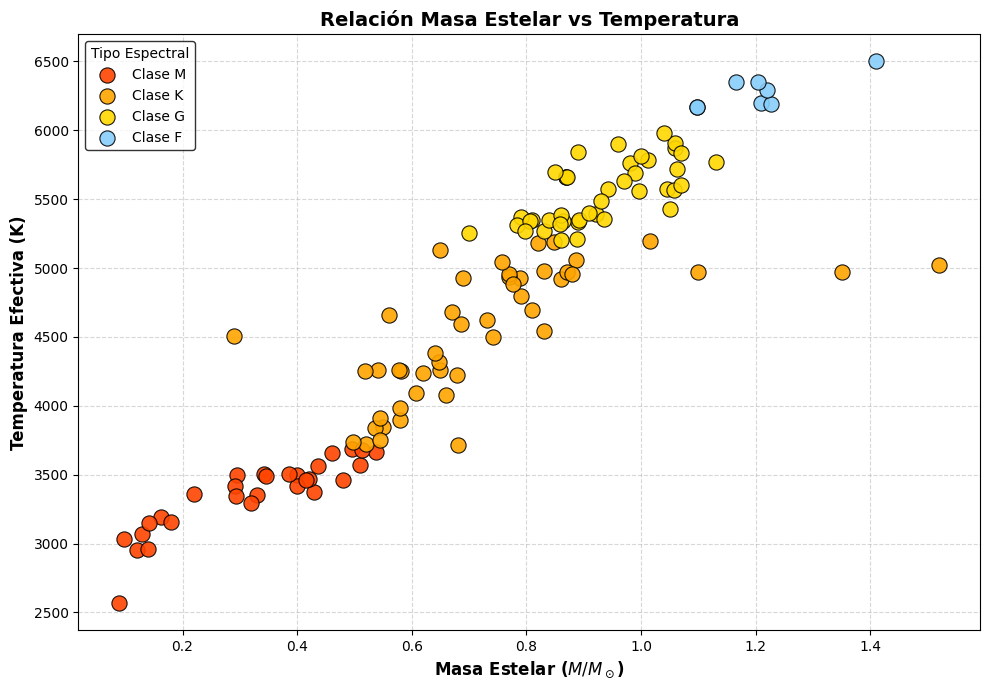

In [7]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

def solicitar_carpetas():
    carpetas = []
    try:
        cantidad = int(input("¿Cuántas carpetas deseas analizar?: "))
        for i in range(cantidad):
            ruta = input(f"Ingresa la ruta de la carpeta {i+1}: ")
            if os.path.exists(ruta):
                carpetas.append(ruta)
            else:
                print(f"⚠️ La ruta '{ruta}' no existe y será ignorada.")
    except ValueError:
        print("❌ Error: Debes ingresar un número entero válido.")
    return carpetas

def clasificar_tipo_espectral(temp):
    if temp == 0: return 'Desconocido'
    elif temp < 3700: return 'M'
    elif temp < 5200: return 'K'
    elif temp < 6000: return 'G'
    elif temp < 7500: return 'F'
    else: return 'O/B/A'

def extraer_datos_de_carpetas(directorios):
    datos_recopilados = []
    
    for directorio_raiz in directorios:
        print(f"\n🔍 Escaneando directorio: {directorio_raiz}...")
        
        for root, dirs, files in os.walk(directorio_raiz):
            resumen_file = next((f for f in files if f.endswith(" resumen.txt") or f.endswith("_resumen.txt")), None)
            readme_file = next((f for f in files if f.startswith("README") and f.endswith(".txt")), None)
            
            if resumen_file and readme_file:
                nombre_planeta = os.path.basename(root).replace("_", " ")
                ruta_resumen = os.path.join(root, resumen_file)
                ruta_readme = os.path.join(root, readme_file)
                
                try:
                    # 1. LEER RESUMEN
                    with open(ruta_resumen, 'r', encoding='utf-8') as f:
                        contenido_resumen = f.read()
                    
                    z_est_match = re.search(r'Total estables:\s*(\d+)', contenido_resumen, re.IGNORECASE)
                    z_est = int(z_est_match.group(1)) if z_est_match else 0
                    
                    # 2. LEER README
                    with open(ruta_readme, 'r', encoding='utf-8') as f:
                        contenido_readme = f.read()
                    
                    # Regex ajustado para tu formato exacto, aunque es lo suficientemente flexible
                    masa_e_match = re.search(r'Masa de la Estrella.*:\s*([0-9.,eE+-]+)', contenido_readme, re.IGNORECASE)
                    temp_e_match = re.search(r'Temperatura Estrella.*:\s*([0-9.,eE+-]+)', contenido_readme, re.IGNORECASE)
                    
                    masa_estel = float(masa_e_match.group(1).replace(',', '.')) if masa_e_match else 0.0
                    temp_estel = float(temp_e_match.group(1).replace(',', '.')) if temp_e_match else 0.0
                    
                    datos_recopilados.append({
                        "Carpeta_Origen": directorio_raiz,
                        "Planeta": nombre_planeta,
                        "Masa_Estrella": masa_estel,
                        "Temp_Estrella_K": temp_estel,
                        "Zonas Estables": z_est,
                        "Tipo_Espectral": clasificar_tipo_espectral(temp_estel)
                    })
                except Exception as e:
                    print(f"❌ Error interno procesando {nombre_planeta}: {e}")
                    
    df_resultados = pd.DataFrame(datos_recopilados)
    if not df_resultados.empty:
        df_resultados["Sistema"] = df_resultados["Planeta"].apply(lambda x: str(x).rsplit(" ", 1)[0])
        df_resultados["Num_Planetas"] = df_resultados.groupby("Sistema")["Planeta"].transform("count")
        
        # Filtrar duplicados para graficar y contar solo una estrella por sistema
        df_estrellas = df_resultados.drop_duplicates(subset=['Sistema']).copy()
        
        # Conteo de estrellas por carpeta
        print("\n" + "="*45)
        print("📊 RESUMEN: ESTRELLAS ÚNICAS POR CARPETA")
        print("="*45)
        conteo_carpetas = df_estrellas.groupby("Carpeta_Origen")["Sistema"].count()
        for carpeta, cantidad in conteo_carpetas.items():
            print(f"📂 {carpeta}: {cantidad} estrella(s)")
        print("="*45 + "\n")
        
        generar_grafico_masa_vs_temp(df_estrellas)
        
    return df_resultados

def generar_grafico_masa_vs_temp(df_estrellas):
    # Filtrar datos inválidos
    df_plot = df_estrellas[(df_estrellas["Temp_Estrella_K"] > 0) & (df_estrellas["Masa_Estrella"] > 0)]
    
    if df_plot.empty:
        print("⚠️ No se encontraron datos válidos de temperatura y masa para generar el gráfico.")
        return

    # Colores visibles en fondo blanco
    colores = {
        'F': '#87CEFA', # Azul claro
        'G': '#FFD700', # Amarillo oro
        'K': '#FFA500', # Naranja
        'M': '#FF4500', # Rojo anaranjado
        'O/B/A': '#4169E1', # Azul rey
        'Desconocido': 'grey'
    }
    
    plt.style.use('default') # Fondo blanco
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Graficar por tipo espectral para armar la leyenda
    for tipo in ['M', 'K', 'G', 'F', 'O/B/A']:
        subset = df_plot[df_plot['Tipo_Espectral'] == tipo]
        if not subset.empty:
            ax.scatter(
                subset['Masa_Estrella'],     # EJE X: Masa
                subset['Temp_Estrella_K'],   # EJE Y: Temperatura
                c=colores[tipo], 
                label=f'Clase {tipo}', 
                edgecolors='black',          # Borde negro para destacar
                linewidth=0.8,
                s=120,
                zorder=3,
                alpha=0.9
            )
            
    # Formato del gráfico
    ax.set_xlabel('Masa Estelar ($M/M_\odot$)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Temperatura Efectiva (K)', fontsize=12, fontweight='bold')
    ax.set_title('Relación Masa Estelar vs Temperatura', fontsize=14, fontweight='bold')
    
    ax.grid(True, linestyle='--', alpha=0.5, zorder=1)
    ax.legend(title="Tipo Espectral", frameon=True, facecolor='white', edgecolor='black')
    
    plt.tight_layout()
    plt.show()

# Ejecución principal
if __name__ == "__main__":
    carpetas_a_escanear = solicitar_carpetas()
    if carpetas_a_escanear:
        df_final = extraer_datos_de_carpetas(carpetas_a_escanear)